# 1. Problem Definition and Understanding

This project uses the **Airbnb Data: Listings Scraped – Global Top Cities** dataset to explore and compare Airbnb listings across nine international destinations.

The dataset includes information about listing prices, overall ratings, property types, listing types, occupancy rates, Superhost status, and other important features that help better understand the characteristics of Airbnb accommodations.

## Dataset Source

Kaggle:
https://www.kaggle.com/datasets/jaeseokanairbtics/airbnb-data-listings-scraped-global-top-10-cities

## 1.1 Problem Definition

The main goal of this project is to explore the Airbnb dataset and identify patterns and differences between destinations based on prices, ratings, property types, listing types, occupancy rates, and other important features.

## 1.2 Key Questions

This EDA focuses on answering questions such as:

- Which destination has the highest and lowest average daily rate?
- Which destination has the highest average overall rating?
- What are the most common property types?
- What is the most common listing type?
- Do Superhosts receive higher ratings than regular hosts?
- Is there a relationship between listing price and overall rating?
- Which destination has the highest average occupancy rate?
- How are the numerical features related to each other?
- How are listing prices distributed, and are there any unusual outliers?

These questions guide the analysis and help extract meaningful insights about Airbnb listings across different destinations.

# 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

#3. Data Loading & Structure

In [ ]:
# Load all Airbnb datasets
dubai = pd.read_csv("DubaiData.csv")
la = pd.read_csv("LAData.csv")
london = pd.read_csv("LondonData.csv")
miami = pd.read_csv("MiamiData.csv")
nyc = pd.read_csv("NYCData.csv")
sf = pd.read_csv("SanFransiscoData.csv")
sydney = pd.read_csv("SydneyData.csv")
tokyo = pd.read_csv("TokyoData.csv")
toronto = pd.read_csv("TorontoData.csv")

In [ ]:
# Add destination column
london["Destination"] = "London"
dubai["Destination"] = "Dubai"
tokyo["Destination"] = "Tokyo"
sydney["Destination"] = "Sydney"
toronto["Destination"] = "Toronto"
miami["Destination"] = "Miami"
nyc["Destination"] = "New York"
la["Destination"] = "Los Angeles"
sf["Destination"] = "San Francisco"

In [ ]:
# Select the required columns
selected_columns = [
    "Destination",
    "City",
    "Property Type",
    "Listing Type",
    "Bedrooms",
    "Bathrooms",
    "Max Guests",
    "Number of Reviews",
    "Overall Rating",
    "Airbnb Cleanliness Rating",
    "Airbnb Location Rating",
    "Airbnb Value Rating",
    "Airbnb Superhost",
    "Latitude",
    "Longitude",
    "Average Daily Rate (USD)",
    "Occupancy Rate LTM"
]

In [ ]:
# Keep the same selected columns in all city datasets before merging them
london = london[selected_columns]
dubai = dubai[selected_columns]
tokyo = tokyo[selected_columns]
sydney = sydney[selected_columns]
toronto = toronto[selected_columns]
miami = miami[selected_columns]
nyc = nyc[selected_columns]
la = la[selected_columns]
sf = sf[selected_columns]

In [ ]:
# Merge all datasets into one dataframe
airbnb = pd.concat(
    [london, dubai, tokyo, sydney, toronto, miami, nyc, la, sf],
    ignore_index=True
)

In [ ]:
airbnb.head()

,Destination,City,Property Type,Listing Type,Bedrooms,Bathrooms,Max Guests,Number of Reviews,Overall Rating,Airbnb Cleanliness Rating,Airbnb Location Rating,Airbnb Value Rating,Airbnb Superhost,Latitude,Longitude,Average Daily Rate (USD),Occupancy Rate LTM
0,London,Colnbrook,Private room in guesthouse,private_room,1,1,2,0,NaN,NaN,NaN,NaN,f,51.47957,-0.50175,120,28
1,London,Colnbrook,Private room in guesthouse,private_room,1,1,1,1,4.0,10.0,8.0,6.0,f,51.47969,-0.50186,67,44
2,London,Claygate,Entire cabin,entire_home,1,1,4,14,4.8,10.0,10.0,10.0,t,51.35414,-0.32597,204,30
3,London,Greater London,Entire home,entire_home,3,2,5,2,NaN,NaN,NaN,NaN,f,51.35664,-0.31363,153,55
4,London,Chessington,Private room in home,private_room,1,1,1,46,5.0,10.0,10.0,10.0,f,51.35778,-0.31369,46,54


In [ ]:
airbnb.shape

(145825, 17)

In [ ]:
airbnb["Destination"].value_counts()

,count
Destination,
London,43580
New York,40343
Dubai,13560
Los Angeles,12837
Miami,10205
Tokyo,9661
Sydney,5938
Toronto,5900
San Francisco,3801


In [ ]:
# Save the merged dataset as a new CSV file
airbnb.to_csv("Airbnb_All_Cities.csv", index=False)

# Download the new CSV file to my computer
files.download("Airbnb_All_Cities.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
airbnb = pd.read_csv("Airbnb_All_Cities.csv")

In [ ]:
airbnb.head()

,Destination,City,Property Type,Listing Type,Bedrooms,Bathrooms,Max Guests,Number of Reviews,Overall Rating,Airbnb Cleanliness Rating,Airbnb Location Rating,Airbnb Value Rating,Airbnb Superhost,Latitude,Longitude,Average Daily Rate (USD),Occupancy Rate LTM
0,London,Colnbrook,Private room in guesthouse,private_room,1,1,2,0,4.8,10.0,10.0,9.0,False,51.47957,-0.50175,120,28
1,London,Colnbrook,Private room in guesthouse,private_room,1,1,1,1,4.0,10.0,8.0,6.0,False,51.47969,-0.50186,67,44
2,London,Claygate,Entire cabin,entire_home,1,1,4,14,4.8,10.0,10.0,10.0,True,51.35414,-0.32597,204,30
3,London,Greater London,Entire home,entire_home,3,2,5,2,4.8,10.0,10.0,9.0,False,51.35664,-0.31363,153,55
4,London,Chessington,Private room in home,private_room,1,1,1,46,5.0,10.0,10.0,10.0,False,51.35778,-0.31369,46,54


In [ ]:
airbnb.shape

(145825, 17)

In [ ]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145825 entries, 0 to 145824
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Destination                145825 non-null  object 
 1   City                       145825 non-null  object 
 2   Property Type              145825 non-null  object 
 3   Listing Type               145825 non-null  object 
 4   Bedrooms                   145825 non-null  object 
 5   Bathrooms                  145825 non-null  int64  
 6   Max Guests                 145825 non-null  int64  
 7   Number of Reviews          145825 non-null  int64  
 8   Overall Rating             124974 non-null  float64
 9   Airbnb Cleanliness Rating  124179 non-null  float64
 10  Airbnb Location Rating     126333 non-null  float64
 11  Airbnb Value Rating        126331 non-null  float64
 12  Airbnb Superhost           145825 non-null  object 
 13  Latitude                   14

In [ ]:
airbnb["Bedrooms"].unique()

array(['1', '3', '4', '2', 'Studio', '5', '0', '7', '6', '10', '8', '16',
       '12', '9', '15', '22', '14', '18', '21', '20', '13', '30', '36',
       '11', '24'], dtype=object)

In [ ]:
airbnb.describe()

,Bathrooms,Max Guests,Number of Reviews,Overall Rating,Airbnb Cleanliness Rating,Airbnb Location Rating,Airbnb Value Rating,Latitude,Longitude,Average Daily Rate (USD),Occupancy Rate LTM
count,145825.000000,145825.000000,145825.000000,124974.000000,124179.000000,126333.000000,126331.000000,145825.000000,145825.000000,145825.000000,145825.000000
mean,1.458481,3.669823,37.542616,4.693068,9.368130,9.530511,9.252638,37.575800,-22.404442,198.687050,67.050890
std,0.858042,2.482226,69.498271,0.466816,1.023195,0.859266,1.046035,17.197563,76.488225,238.648368,26.722573
min,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,2.000000,-34.095835,-122.511360,1.000000,1.000000
25%,1.000000,2.000000,2.000000,4.500000,9.000000,9.000000,9.000000,34.081050,-74.243940,86.000000,46.000000
50%,1.000000,3.000000,11.000000,4.800000,10.000000,10.000000,9.000000,40.725000,-73.254020,143.000000,70.000000
75%,2.000000,4.000000,42.000000,5.000000,10.000000,10.000000,10.000000,51.464510,-0.052462,235.000000,92.000000
max,42.000000,42.000000,2383.000000,5.000000,10.000000,10.000000,10.000000,51.676290,151.340140,33553.000000,100.000000


In [ ]:
airbnb.isnull().sum()

,0
Destination,0
City,0
Property Type,0
Listing Type,0
Bedrooms,0
Bathrooms,0
Max Guests,0
Number of Reviews,0
Overall Rating,20851
Airbnb Cleanliness Rating,21646


In [ ]:
airbnb.duplicated().sum()

np.int64(27)

#4. Data cleaning

In [ ]:
airbnb = airbnb.drop_duplicates()

In [ ]:
airbnb.duplicated().sum()

np.int64(0)

In [ ]:
airbnb["Bedrooms"] = airbnb["Bedrooms"].replace("Studio", 0)

In [ ]:
airbnb["Bedrooms"] = airbnb["Bedrooms"].astype(int)

In [ ]:
airbnb["Bedrooms"].dtype

dtype('int64')

In [ ]:
rating_columns = [
    "Overall Rating",
    "Airbnb Cleanliness Rating",
    "Airbnb Location Rating",
    "Airbnb Value Rating"
]

for col in rating_columns:
    airbnb[col] = airbnb[col].fillna(airbnb[col].median())

In [ ]:
airbnb[rating_columns].isnull().sum()

,0
Overall Rating,0
Airbnb Cleanliness Rating,0
Airbnb Location Rating,0
Airbnb Value Rating,0


In [ ]:
airbnb["Airbnb Superhost"] = airbnb["Airbnb Superhost"].replace({"t": True,"f": False})

/tmp/ipykernel_2042/367604775.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  airbnb["Airbnb Superhost"] = airbnb["Airbnb Superhost"].replace({"t": True,"f": False})


In [ ]:
airbnb["Airbnb Superhost"].dtype

dtype('bool')

In [ ]:
airbnb.dtypes

,0
Destination,object
City,object
Property Type,object
Listing Type,object
Bedrooms,int64
Bathrooms,int64
Max Guests,int64
Number of Reviews,int64
Overall Rating,float64
Airbnb Cleanliness Rating,float64


In [ ]:
airbnb.isnull().sum()

,0
Destination,0
City,0
Property Type,0
Listing Type,0
Bedrooms,0
Bathrooms,0
Max Guests,0
Number of Reviews,0
Overall Rating,0
Airbnb Cleanliness Rating,0


In [ ]:
airbnb.to_csv("Airbnb_Cleaned.csv", index=False)

In [ ]:
files.download("Airbnb_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#5. Exploratory Data Analysis (EDA)

In [ ]:
airbnb = pd.read_csv("Airbnb_Cleaned.csv")

In [ ]:
average_price = airbnb.groupby("Destination")["Average Daily Rate (USD)"].mean().sort_values(ascending=False)
average_price

,Average Daily Rate (USD)
Destination,
Los Angeles,243.856275
San Francisco,227.772954
Miami,209.597060
London,208.170897
New York,207.671056
Sydney,199.249747
Dubai,164.655432
Toronto,129.826610
Tokyo,124.762191


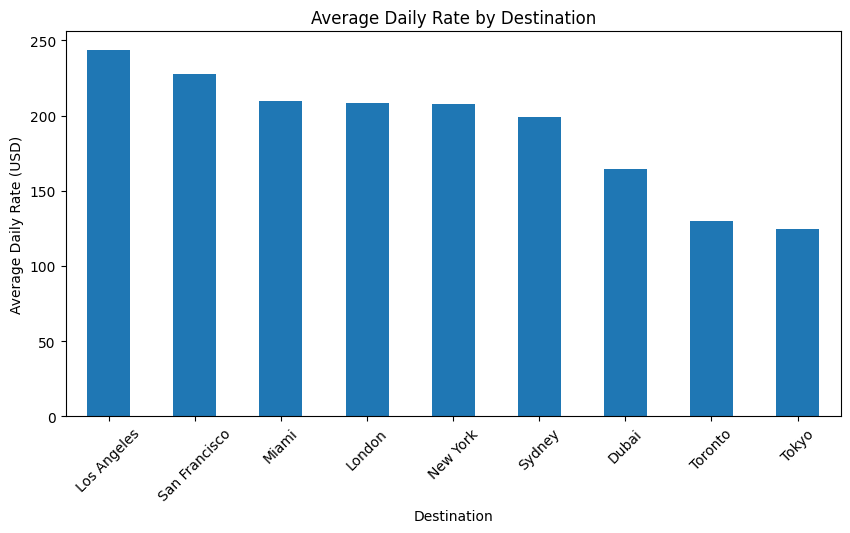

In [ ]:
plt.figure(figsize=(10,5))
average_price.plot(kind="bar")

plt.title("Average Daily Rate by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Daily Rate (USD)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
rating_by_destination = airbnb.groupby("Destination")["Overall Rating"].mean().sort_values(ascending=False)
rating_by_destination

,Overall Rating
Destination,
Toronto,4.783220
San Francisco,4.781479
Miami,4.773239
Los Angeles,4.747114
New York,4.740297
Sydney,4.718390
Tokyo,4.690755
London,4.661139
Dubai,4.634449


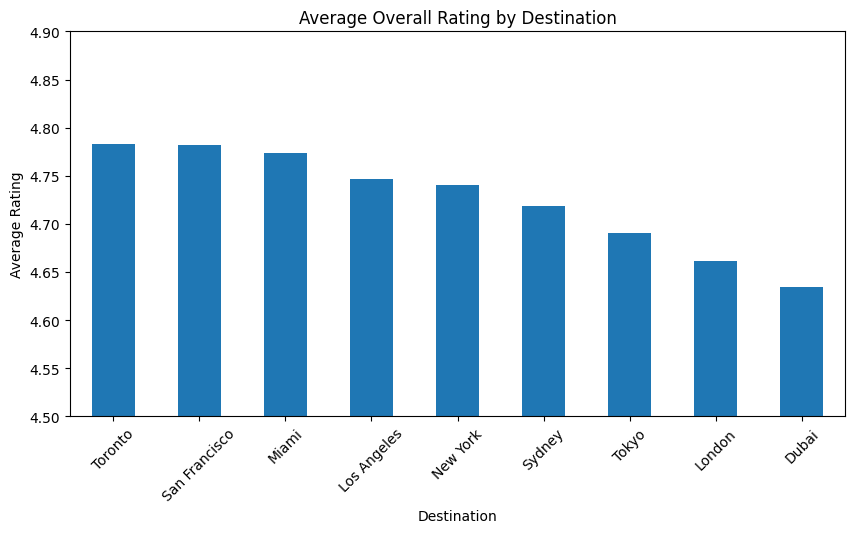

In [ ]:
plt.figure(figsize=(10,5))
rating_by_destination.plot(kind="bar")

plt.title("Average Overall Rating by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(4.5, 4.9)

plt.show()

In [ ]:
top_property = airbnb["Property Type"].value_counts().head(10)
top_property

,count
Property Type,
Entire rental unit,56840
Entire home,17133
Private room in rental unit,13717
Private room in home,13063
Entire condo,12672
Entire serviced apartment,3446
Private room in condo,2906
Entire guest suite,2592
Room in hotel,2184


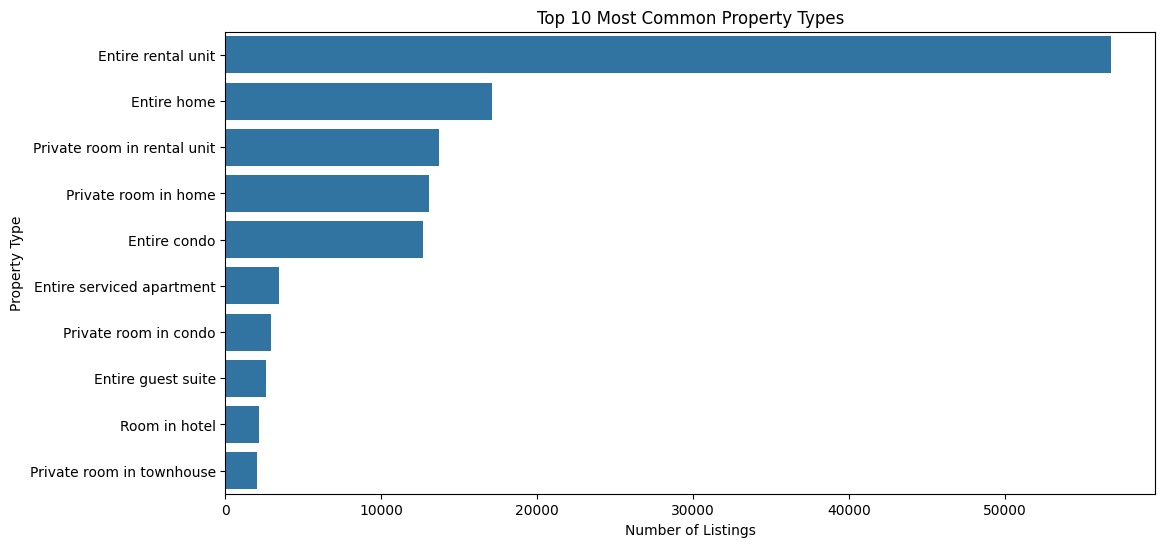

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=airbnb,y="Property Type",order=top_property.index)

plt.title("Top 10 Most Common Property Types")
plt.xlabel("Number of Listings")
plt.ylabel("Property Type")

plt.show()

In [ ]:
listing_counts = airbnb["Listing Type"].value_counts()
listing_counts

,count
Listing Type,
entire_home,104088
private_room,39273
shared_room,1547
hotel_room,890


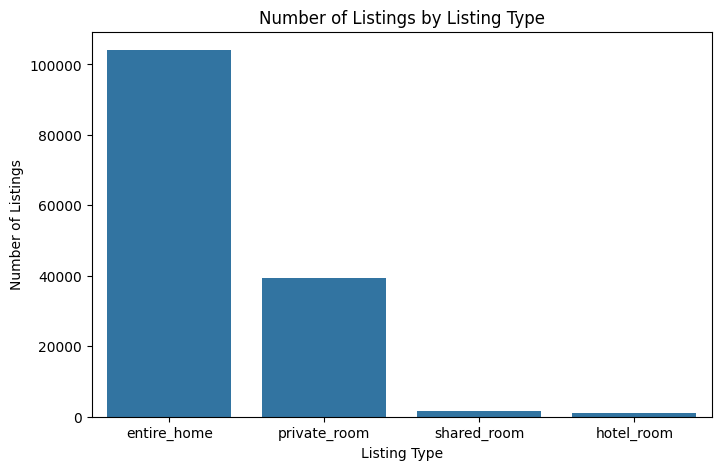

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=airbnb,x="Listing Type",order=listing_counts.index)

plt.title("Number of Listings by Listing Type")
plt.xlabel("Listing Type")
plt.ylabel("Number of Listings")

plt.show()

In [ ]:
superhost_rating = airbnb.groupby("Airbnb Superhost")["Overall Rating"].mean()
superhost_rating

,Overall Rating
Airbnb Superhost,
False,4.633416
True,4.870757


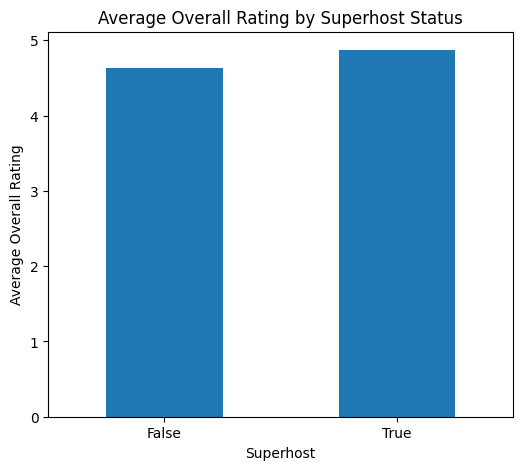

In [ ]:
plt.figure(figsize=(6,5))
superhost_rating.plot(kind="bar")

plt.title("Average Overall Rating by Superhost Status")
plt.xlabel("Superhost")
plt.ylabel("Average Overall Rating")
plt.xticks(rotation=0)

plt.show()

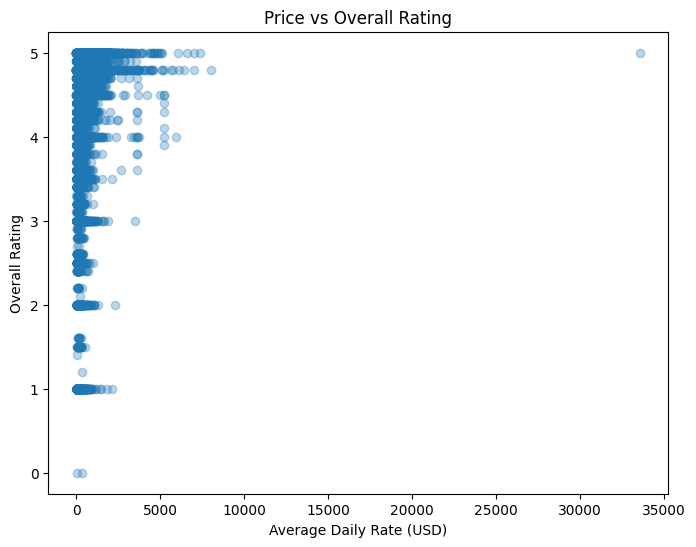

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter( airbnb["Average Daily Rate (USD)"], airbnb["Overall Rating"], alpha=0.3)

plt.title("Price vs Overall Rating")
plt.xlabel("Average Daily Rate (USD)")
plt.ylabel("Overall Rating")

plt.show()

In [ ]:
occupancy_by_destination = airbnb.groupby("Destination")["Occupancy Rate LTM"].mean().sort_values(ascending=False)
occupancy_by_destination

,Occupancy Rate LTM
Destination,
Tokyo,83.348069
Sydney,70.549680
London,70.045002
Toronto,68.402373
San Francisco,65.451723
New York,64.354140
Dubai,63.888635
Los Angeles,60.702734
Miami,59.506810


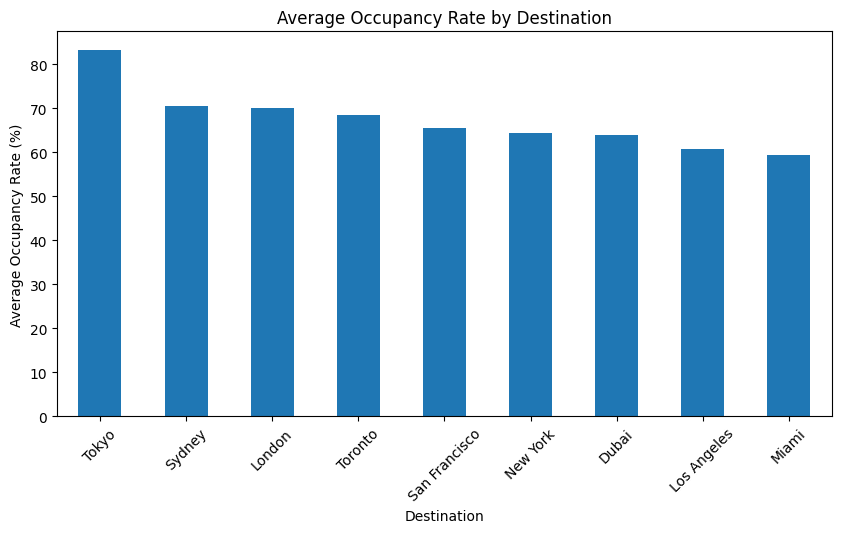

In [ ]:
plt.figure(figsize=(10,5))
occupancy_by_destination.plot(kind="bar")

plt.title("Average Occupancy Rate by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Occupancy Rate (%)")
plt.xticks(rotation=45)

plt.show()

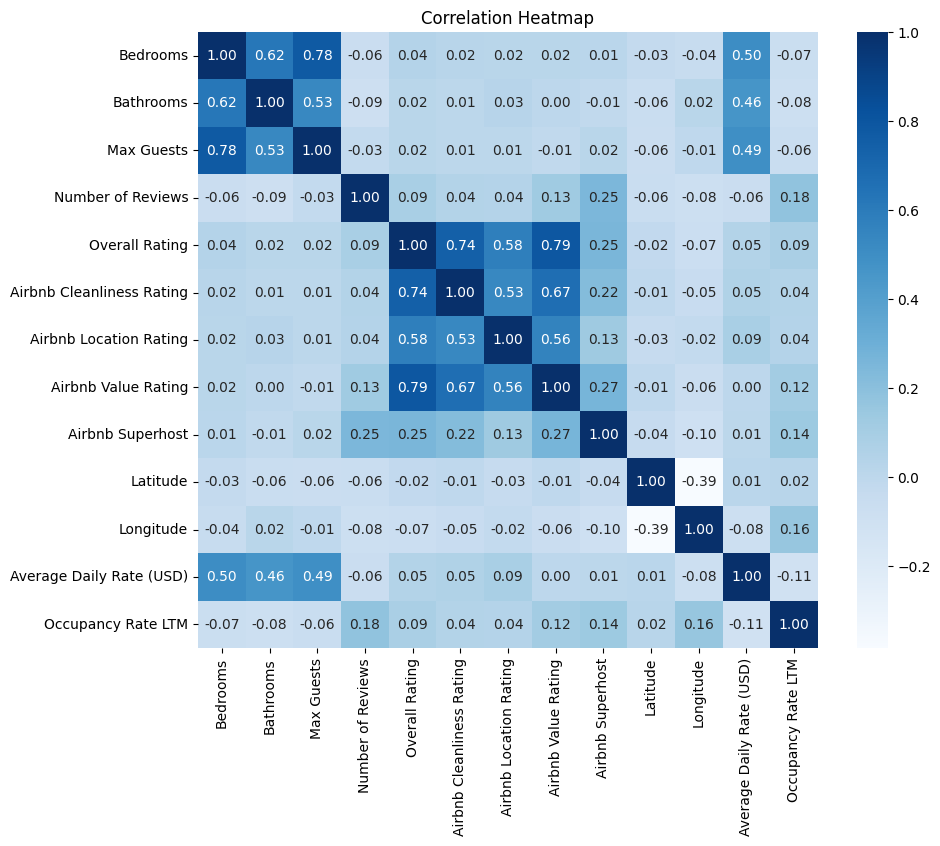

In [ ]:
plt.figure(figsize=(10,8))
correlation = airbnb.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

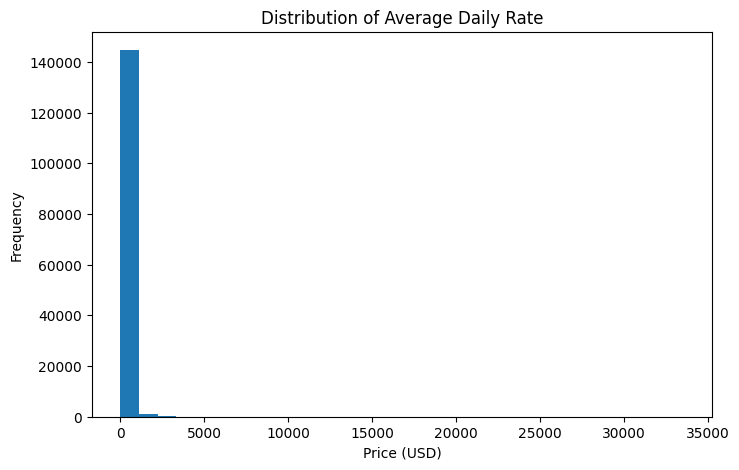

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(airbnb["Average Daily Rate (USD)"], bins=30)

plt.title("Distribution of Average Daily Rate")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.show()

###Outlier Investigation

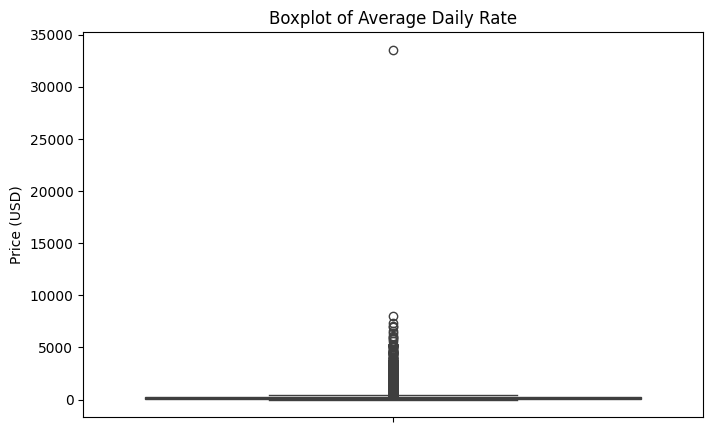

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(airbnb["Average Daily Rate (USD)"])

plt.title("Boxplot of Average Daily Rate")
plt.ylabel("Price (USD)")

plt.show()

The boxplot shows the presence of an extreme outlier in the **Average Daily Rate (USD)** column.

The highest price in the dataset is **33,553 USD**, which is much higher than the rest of the listing prices. This value requires further investigation to determine whether it is a valid observation or an unrealistic value.

In [ ]:
airbnb = pd.read_csv("Airbnb_Cleaned.csv")

In [ ]:
#dealing with outlaier
airbnb.sort_values("Average Daily Rate (USD)", ascending=False).head(10)

,Destination,City,Property Type,Listing Type,Bedrooms,Bathrooms,Max Guests,Number of Reviews,Overall Rating,Airbnb Cleanliness Rating,Airbnb Location Rating,Airbnb Value Rating,Airbnb Superhost,Latitude,Longitude,Average Daily Rate (USD),Occupancy Rate LTM
133827,Los Angeles,Beverly Hills,Entire guesthouse,entire_home,1,1,4,58,5.0,10.0,10.0,10.0,False,34.085240,-118.421750,33553,96
31817,London,Greater London,Entire home,entire_home,6,5,14,0,4.8,10.0,10.0,9.0,False,51.500000,-0.174000,8031,27
79514,Miami,Miami Beach,Entire home,entire_home,8,7,15,37,5.0,10.0,10.0,9.0,False,25.789690,-80.175820,7392,50
20239,London,Greater London,Entire home,entire_home,5,5,11,0,4.8,10.0,10.0,9.0,False,51.450000,-0.172650,7035,27
101512,New York,Wawarsing,Entire villa,entire_home,12,13,16,2,5.0,10.0,10.0,10.0,True,41.805790,-74.377210,7000,34
50899,Dubai,Dubai,Entire villa,entire_home,7,8,14,1,5.0,10.0,10.0,10.0,False,25.124030,55.129940,6565,40
85875,Miami,Miami,Entire home,entire_home,5,9,12,1,4.8,10.0,6.0,8.0,False,25.837750,-80.179980,6382,24
34032,London,London,Entire home,entire_home,5,3,12,0,4.8,10.0,10.0,9.0,False,51.540170,-0.184370,6116,65
133830,Los Angeles,Beverly Hills,Entire home,entire_home,7,10,14,1,5.0,10.0,10.0,10.0,False,34.084343,-118.407515,6045,63
37872,London,London,Entire home,entire_home,5,3,10,4,4.0,10.0,9.0,8.0,False,51.543950,-0.097970,5933,29


In [ ]:
airbnb[airbnb["Average Daily Rate (USD)"] > 10000]

,Destination,City,Property Type,Listing Type,Bedrooms,Bathrooms,Max Guests,Number of Reviews,Overall Rating,Airbnb Cleanliness Rating,Airbnb Location Rating,Airbnb Value Rating,Airbnb Superhost,Latitude,Longitude,Average Daily Rate (USD),Occupancy Rate LTM
133827,Los Angeles,Beverly Hills,Entire guesthouse,entire_home,1,1,4,58,5.0,10.0,10.0,10.0,False,34.08524,-118.42175,33553,96


In [ ]:
# Remove the unrealistic price outlier
airbnb = airbnb[airbnb["Average Daily Rate (USD)"] <= 10000]

In [ ]:
#just making sure
airbnb["Average Daily Rate (USD)"].max()

8031

In [ ]:
airbnb.to_csv("Airbnb_Cleaned_Final.csv", index=False)

In [ ]:
files.download("Airbnb_Cleaned_Final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
airbnb = pd.read_csv("Airbnb_Cleaned_Final.csv")

## Re-analysis After Removing the Outlier

After removing the unrealistic outlier, the visualizations directly affected by the listing price were recreated. This ensures that the results accurately represent the dataset without being influenced by the extreme value.

In [ ]:
# After removing the outlier
price_by_destination = (airbnb.groupby("Destination")["Average Daily Rate (USD)"].mean().sort_values(ascending=False))
price_by_destination

,Average Daily Rate (USD)
Destination,
Los Angeles,241.261296
San Francisco,227.772954
Miami,209.597060
London,208.170897
New York,207.671056
Sydney,199.249747
Dubai,164.655432
Toronto,129.826610
Tokyo,124.762191


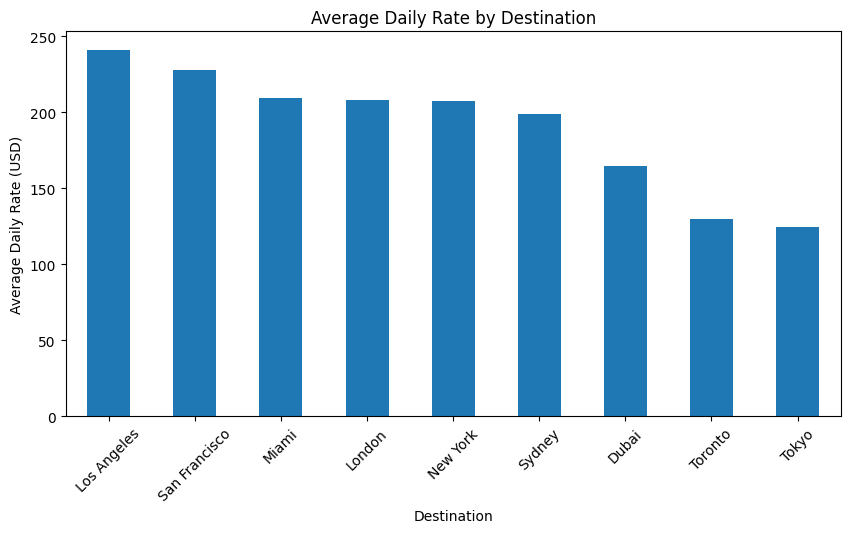

In [ ]:
plt.figure(figsize=(10, 5))
price_by_destination.plot(kind="bar")

plt.title("Average Daily Rate by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Daily Rate (USD)")
plt.xticks(rotation=45)

plt.show()

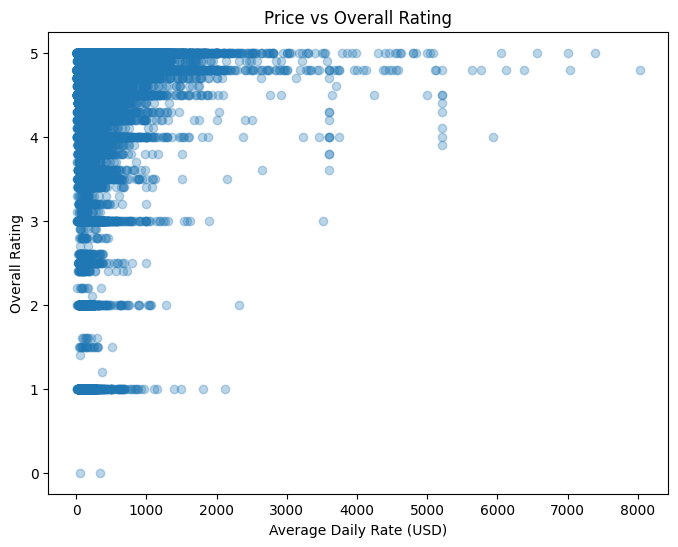

In [ ]:
# After removing the outlier
plt.figure(figsize=(8, 6))
plt.scatter(
    airbnb["Average Daily Rate (USD)"],
    airbnb["Overall Rating"],
    alpha=0.3
)

plt.title("Price vs Overall Rating")
plt.xlabel("Average Daily Rate (USD)")
plt.ylabel("Overall Rating")

plt.show()

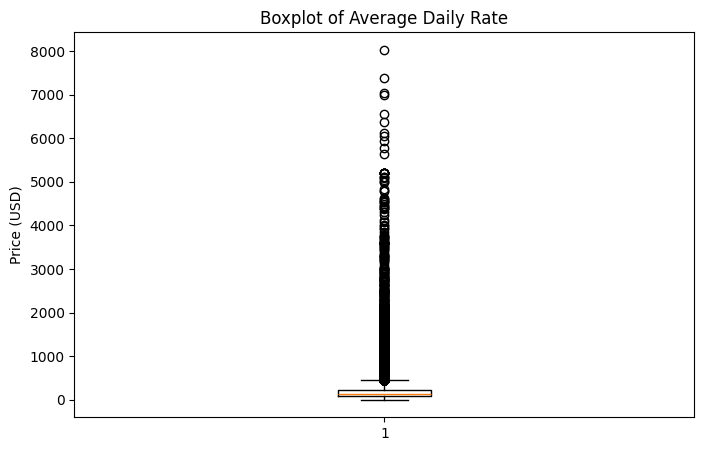

In [ ]:
# After removing the outlier
plt.figure(figsize=(8, 5))
plt.boxplot(airbnb["Average Daily Rate (USD)"])

plt.title("Boxplot of Average Daily Rate")
plt.ylabel("Price (USD)")

plt.show()

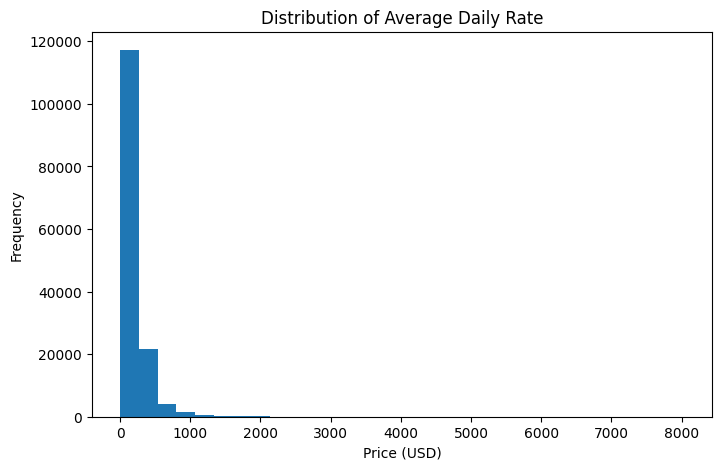

In [ ]:
# After removing the outlier
plt.figure(figsize=(8, 5))
plt.hist(
    airbnb["Average Daily Rate (USD)"],
    bins=30
)

plt.title("Distribution of Average Daily Rate")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.show()

# 6. Final Insights Summary

After exploring the Airbnb Listings dataset and answering the key analytical questions, here are the main insights:

---

## 1. Average Daily Rate by Destination

**Insight:**

Los Angeles has the highest average daily rate, while Tokyo has the lowest average daily rate among the selected destinations.

This indicates that accommodation prices vary noticeably between cities, reflecting differences in demand and local markets.

---

## 2. Average Overall Rating by Destination

**Insight:**

Toronto and San Francisco have the highest average overall ratings, while Dubai has the lowest average rating.

Although the differences are relatively small, they suggest slight variations in guest satisfaction across destinations.

---

## 3. Top 10 Most Common Property Types

**Insight:**

The most common property type is **Entire rental unit**, followed by **Entire home**.

This shows that complete accommodations are more commonly offered than shared or private property types.

---

## 4. Number of Listings by Listing Type

**Insight:**

**Entire home** is by far the most common listing type, followed by **Private room**.

Shared rooms and hotel rooms represent only a small portion of all listings.

---

## 5. Average Overall Rating by Superhost Status

**Insight:**

Listings hosted by **Superhosts** have a higher average overall rating than listings hosted by regular hosts.

This suggests that Superhosts generally provide a better guest experience.

---

## 6. Price vs Overall Rating

**Insight:**

There is no strong relationship between listing price and overall rating.

Higher-priced listings do not necessarily receive better guest ratings.

---

## 7. Average Occupancy Rate by Destination

**Insight:**

Tokyo has the highest average occupancy rate, while Miami has the lowest occupancy rate among the selected destinations.

This suggests that demand for Airbnb listings differs across cities.

---

## 8. Correlation Heatmap

**Insight:**

The strongest positive correlations are between **Overall Rating**, **Airbnb Value Rating**, and **Airbnb Cleanliness Rating**.

This indicates that guests who give high overall ratings also tend to give high ratings for value and cleanliness.

---

## 9. Distribution of Average Daily Rate

**Insight:**

The distribution of listing prices is highly right-skewed, with most listings concentrated in the lower price range.

An unrealistic outlier (**33,553 USD**) was identified, investigated, and removed. Re-plotting the affected visualizations after removing this value produced a more representative analysis.

---

## Overall Conclusion

Accommodation prices, occupancy rates, and guest ratings vary across destinations. Entire rental units and entire homes dominate the Airbnb market, while Superhosts consistently receive higher ratings than regular hosts.

The analysis also shows that guest satisfaction is more closely related to listing quality than to price. Finally, identifying and removing the unrealistic outlier improved the accuracy and reliability of the overall analysis.